1. LSTM이 왜 긴 문장을 잘 못 기억하는가
2. Attention이 어떻게 그 문제를 해결하는가
3. Query, Key, Value를 어떻게 직관적으로 이해할 수 있는가
4. Self-Attention이 왜 강력한가
5. Transformer가 왜 Attention을 중심으로 설계되었는가

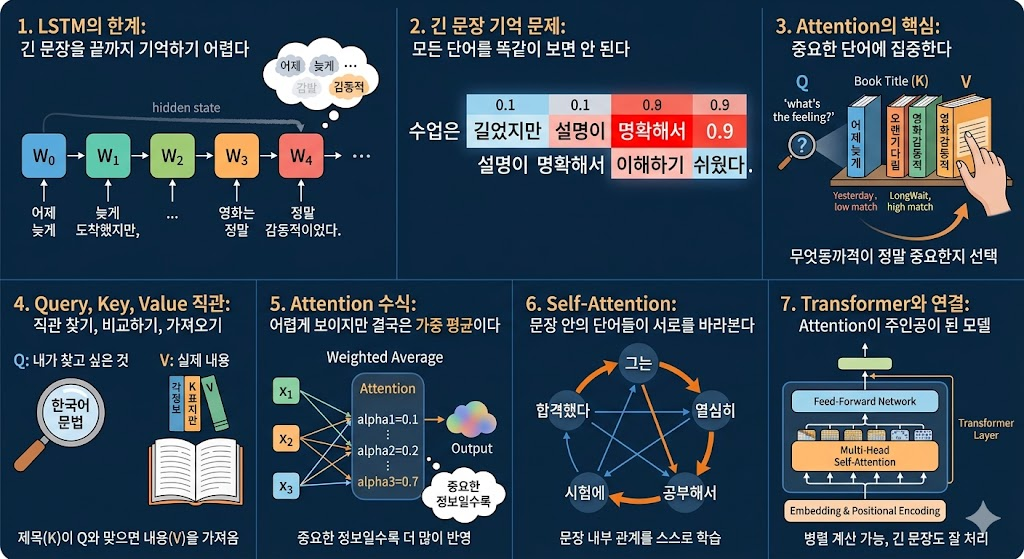

## 1. LSTM의 한계: 긴 문장을 끝까지 기억하기 어렵다

LSTM은 RNN의 약점을 보완한 모델이지만, 문장이 길어지면 여전히 앞부분 정보가 뒤까지 온전히 전달되기 어렵다. 마치 긴 회의 내용을 마지막 사람에게 전달하는데, 중간에 몇 명만 거치면 처음 이야기가 흐려지는 것과 같다.

LSTM은 gate를 통해 정보를 조절하지만, 모든 단어를 같은 비중으로 저장할 수는 없다. 결국 오래된 정보는 점점 약해지고, 중요한 단서가 사라질 수 있다.

### 왜 문제가 되는가

예를 들어 한국어 문장:

> "어제 늦게 도착했지만, 오랜 기다림 끝에 본 영화는 정말 감동적이었다."

이 문장에서 감정을 결정하는 핵심은 뒤쪽의 "감동적이었다"이다. 하지만 앞의 "늦게 도착했지만" 같은 정보와 섞이면서, LSTM은 전체 감정을 안정적으로 잡기 어려울 수 있다.

### 수식으로 보는 느낌

LSTM은 보통 다음과 같이 상태를 갱신한다.

$$
i_t = \sigma(W_i x_t + U_i h_{t-1} + b_i)
$$

$$
f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)
$$

$$
o_t = \sigma(W_o x_t + U_o h_{t-1} + b_o)
$$

$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

여기서 중요한 점은, 과거 정보가 $c_{t-1}$에 남더라도 게이트를 거치며 점점 희석될 수 있다는 것이다. 즉, “무엇이 정말 중요한지”를 매 시점 자동으로 강하게 선택해 주지는 못한다.

### 예제 문장

- "이 영화는 초반은 지루했지만, 결말이 아주 훌륭했다."

이 문장에서 분류의 핵심은 "결말이 아주 훌륭했다"이다. 긴 문장일수록 뒷부분의 중요한 단어를 안정적으로 잡아야 한다.

## 2. 긴 문장 기억 문제: 모든 단어를 똑같이 보면 안 된다

### 핵심 직관

사람도 긴 문장을 읽을 때 모든 단어를 동일하게 기억하지 않는다. 중요한 단어에 밑줄을 긋듯, 모델도 핵심 단어에 더 높은 주의를 줘야 한다.

예를 들어 다음 문장에서 감정을 판단할 때:

> "음식은 평범했지만, 직원의 친절함 덕분에 기분 좋게 식사했다."

"직원의 친절함", "기분 좋게"는 감정 판단에 매우 중요하다. 반면 "음식은 평범했지만"은 보조 정보에 가깝다.

### Attention이 필요한 이유

Attention은 문장 전체를 한 덩어리로 압축하지 않고, 필요한 순간마다 "어떤 단어를 더 볼지" 선택하게 만든다. 그래서 긴 문장에서도 중요한 정보가 사라질 가능성이 줄어든다.

### 비유

도서관에서 책 한 권을 찾을 때, 모든 페이지를 처음부터 끝까지 똑같이 외우지 않는다. 색인이나 목차를 보고 필요한 부분으로 바로 간다. Attention은 바로 그 "색인" 같은 역할을 한다.

### 예제 문장

- "수업은 길었지만 설명이 명확해서 이해하기 쉬웠다."

이 문장에서 핵심은 "설명이 명확해서 이해하기 쉬웠다"이다. 긴 앞부분보다 뒤의 판단 단어가 더 중요하다.

## 3. Attention의 핵심: 중요한 단어에 집중한다

### 핵심 직관

Attention은 말 그대로 "주의를 주는 메커니즘"이다. 모델이 문장을 볼 때 모든 단어에 같은 힘을 쓰지 않고, 현재 필요한 정보에 더 많은 비중을 준다.

예를 들어 번역할 때 영어 문장 "I ate an apple"을 한국어로 옮기면, "apple"이라는 단어를 볼 때 모델은 이전 문장 전체가 아니라 관련 단어에 더 강하게 반응해야 한다.

### 아주 쉬운 비유

친구가 "어제 본 영화는 재미없었지만 음악은 좋았어"라고 말하면, 감정을 요약할 때 사람은 "재미없었지만"과 "좋았어"를 먼저 본다. Attention도 이처럼 문장 속에서 결정적인 단어를 골라 본다.

### 기본 수식

Attention은 일반적으로 다음처럼 표현한다.

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

여기서 중요한 것은 수식 자체보다 역할이다.

- $Q$는 지금 무엇을 찾고 있는지
- $K$는 각 단어가 어떤 특징을 가지고 있는지
- $V$는 실제로 가져올 정보

### 예제 문장

- "그 카페는 분위기는 좋았지만 커피 맛은 아쉬웠다."

이 문장에서 감정 판단에는 "아쉬웠다"가 더 중요하므로 Attention은 그 단어에 더 높은 가중치를 줄 수 있다.

## 4. Query, Key, Value 직관: 찾기, 비교하기, 가져오기

### 직관적 정의

이 세 단어를 검색 시스템으로 이해하면 쉽다.

- Query: 내가 지금 찾고 싶은 것
- Key: 각 정보가 가진 표지판
- Value: 실제로 가져갈 내용

### 비유 1: 도서관

도서관에서 "한국어 문법" 책을 찾는다고 하자.

- Query는 "한국어 문법"을 찾는 내 요청
- Key는 각 책 등에 붙은 제목, 주제, 분류 번호
- Value는 책의 실제 내용

제목(Key)이 Query와 잘 맞는 책을 찾으면, 그 책의 내용(Value)을 읽는다.

### 비유 2: 식당 추천

"매운 음식"을 찾는다면:

- Query: 매운 음식을 먹고 싶다
- Key: 각 메뉴의 특징 태그
- Value: 실제 메뉴 정보

태그가 잘 맞는 메뉴를 더 크게 참고하게 된다.

### 수식으로 보는 점수 계산

Query와 Key의 유사도는 보통 내적으로 계산한다.

$$
score(q, k_i) = q \cdot k_i
$$

점수를 모두 계산한 뒤 softmax로 확률처럼 바꾼다.

$$
\alpha_i = \frac{e^{score(q, k_i)}}{\sum_j e^{score(q, k_j)}}
$$

마지막으로 Value를 가중합한다.

$$
output = \sum_i \alpha_i v_i
$$

즉, 중요한 정보일수록 $\alpha_i$가 크고, 결과에 더 많이 반영된다.

### 예제 문장

- "영화는 길었지만 결말이 강렬해서 기억에 남았다."

Query가 "기억에 남은 이유"라면 Key 중 "결말이 강렬해서"가 가장 높은 점수를 받을 가능성이 크다.

## 5. Attention 수식: 어렵게 보이지만 결국은 가중 평균이다

### 핵심 직관

Attention의 본질은 복잡한 공식을 가진 특별한 마법이 아니라, "중요한 것에 더 큰 비중을 두는 가중 평균"이다.

예를 들어 세 사람의 의견을 반영할 때, 가장 경험 많은 사람 의견에 더 큰 가중치를 줄 수 있다. Attention도 문장 속 단어들에게 그런 방식으로 비중을 준다.

### 대표 수식

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

이 수식은 세 단계로 읽으면 쉽다.

1. Query와 Key의 유사도를 계산한다.
2. softmax로 중요도를 정규화한다.
3. Value를 중요도에 따라 섞는다.

### 왜 $\sqrt{d_k}$로 나누는가

차원이 커질수록 내적 값이 너무 커질 수 있다. 그러면 softmax가 한쪽으로 쏠려 학습이 불안정해진다. 그래서 $\sqrt{d_k}$로 나누어 점수를 적당한 크기로 만든다.

### 예제 문장

- "오늘은 비가 왔지만 산책은 즐거웠다."

이 문장에서는 "즐거웠다"가 최종 감정에 더 큰 영향을 주며, Attention은 그쪽에 더 큰 비중을 줄 수 있다.

## 6. Self-Attention: 문장 안의 단어들이 서로를 바라본다

### 핵심 직관

Self-Attention은 말 그대로 "자기 자신 안에서 서로를 참고하는 Attention"이다. 문장 안의 각 단어가 다른 단어들과 관계를 맺는다.

예를 들어:

> "그 학생은 시험이 끝난 뒤 매우 안심했다."

여기서 "안심했다"는 "시험이 끝난 뒤"와 강하게 연결된다. Self-Attention은 이런 관계를 학습한다.

### 왜 중요한가

RNN처럼 순서대로만 읽지 않고, 모든 단어가 한꺼번에 다른 모든 단어를 볼 수 있다. 그래서 "먼 단어와의 관계"를 잡기 좋다.

### Self-Attention 수식

입력 $X$로부터 Query, Key, Value를 모두 만든다.

$$
Q = XW_Q, \quad K = XW_K, \quad V = XW_V
$$

그리고 같은 식을 사용한다.

$$
Self-Attention(X) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

여기서 중요한 점은 $Q$, $K$, $V$가 모두 같은 문장에서 나온다는 것이다. 즉, 문장 내부의 관계를 스스로 학습한다.

### 예제 문장

- "그는 열심히 공부해서 시험에 합격했다."

Self-Attention은 "합격했다"와 "열심히 공부해서"의 관계를 강하게 잡을 수 있다.

## 7. Transformer와 연결: Attention이 주인공이 된 모델

### 핵심 직관

Transformer는 RNN이나 LSTM처럼 순차적으로 한 칸씩 처리하지 않는다. 대신 Attention으로 문장 전체를 한 번에 바라본다. 그래서 병렬 계산이 가능하고, 긴 문장도 더 잘 다룬다.

### Transformer가 강한 이유

- 문장 전체를 동시에 볼 수 있다
- Self-Attention으로 단어 관계를 직접 계산한다
- 긴 거리 의존성을 더 잘 잡는다
- 학습 속도가 빠르다

### 구조 이해

Transformer의 Encoder는 대략 다음 흐름이다.

1. 단어를 임베딩한다
2. Positional Encoding으로 위치 정보를 더한다
3. Multi-Head Self-Attention을 적용한다
4. Feed-Forward Network를 통과한다

Decoder는 여기에 마스킹과 Cross-Attention이 추가된다.

### 왜 위치 정보가 필요한가

Attention은 단어 순서를 본질적으로 알지 못한다. 따라서 "오늘 비가 왔다"와 "비가 오늘 왔다"를 구분하려면 Positional Encoding이 필요하다.

### 대표 수식

Transformer의 Attention도 기본적으로 같은 수식을 쓴다.

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

다만 여러 개의 Head를 동시에 사용한다.

$$
MultiHead(Q, K, V) = Concat(head_1, \ldots, head_h)W_O
$$

$$
head_i = Attention(QW_Q^i, KW_K^i, VW_V^i)
$$

여러 Head는 같은 문장을 서로 다른 관점에서 본다. 하나는 문법 관계를, 다른 하나는 의미 관계를, 또 다른 하나는 장거리 의존성을 볼 수 있다.

### 예제 문장

- "비가 많이 와서 길이 미끄러웠지만, 행사는 무사히 끝났다."

Transformer는 "무사히 끝났다"와 "행사"의 관계를 Self-Attention으로 직접 연결해 더 안정적으로 문맥을 이해할 수 있다.

## 8. 한 번에 정리하는 직관 요약

### 한 줄 요약

Attention은 "지금 필요한 정보가 어디 있는지 찾고, 그 정보에 더 큰 비중을 주는 방법"이다.

### 기억할 핵심

- LSTM은 긴 문장에서 정보가 흐려질 수 있다
- Attention은 중요한 단어에 집중하게 만든다
- Query는 찾고 싶은 것, Key는 표지판, Value는 실제 내용이다
- Self-Attention은 문장 안의 단어들이 서로를 참고하는 방식이다
- Transformer는 Attention을 중심으로 만든 모델이다

### 최종 비유

문장 이해를 여행에 비유하면, LSTM은 처음부터 끝까지 한 길로만 가는 여행이고, Attention은 지도를 보며 중요한 장소만 골라 찾아가는 여행이다. Transformer는 그 지도를 아주 정교하게 만든 고급 내비게이션이라고 생각하면 된다.

### 예제 문장

- "이 책은 처음엔 어려웠지만, 끝까지 읽으니 매우 유익했다."

이 문장에서 최종 판단은 "매우 유익했다"이다. Attention과 Transformer는 이런 핵심 신호를 더 잘 잡는 구조다.